In [17]:
# import libraries

import numpy as np
import pandas as pd
import geopandas as gpd

import json

import matplotlib.pyplot as plt

import leafmap.maplibregl as leafmap

import os

Import files

In [18]:
# Load total pop
total_pop_folder = "Population Data"
pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_age_breakdown.parquet"))

# Load student pop
student_pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_stu_breakdown.parquet"))

# Load school pop
school_folder = "School Data"
school_gdf = gpd.read_parquet(os.path.join(school_folder, "swk_list_of_schools_2025.parquet"))

# Load combined routes
routes_folder = "OSRM Routes to Nearest School"
secondary_combined_routes_gdf = gpd.read_parquet(os.path.join(routes_folder, "secondary_combined_routes.parquet"))
primary_combined_routes_gdf = gpd.read_parquet(os.path.join(routes_folder, "primary_combined_routes.parquet"))

# Load aggregated data
aggregated_data_folder = "Aggregated Data"
district_time_stats_df = pd.read_csv(os.path.join(aggregated_data_folder,"district_summary_statistics_time_min.csv"))

# Boundaries
boundary_folder = "Geographic Boundaries"
swk_districts_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_districts.geojson")) # District boundaries
swk_parlimen_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_parliament.geojson")) # Parlimen boundaries
swk_dun_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_dun.geojson")) # DUN boundaries

In [19]:
# Create total, primary and secondary population gdfs
total_pop_gdf = pop_gdf.copy()[["id","total_pop","x","y","bandar_luarbandar","geometry"]]
primary_pop_gdf = student_pop_gdf.copy()[["id","primary_school_students","x","y","bandar_luarbandar","geometry"]]
secondary_pop_gdf = student_pop_gdf.copy()[["id","secondary_school_students","x","y","bandar_luarbandar","geometry"]]

# Round numbders
total_pop_gdf["total_pop"] = total_pop_gdf["total_pop"].round(0).astype(int)
primary_pop_gdf["primary_school_students"] = primary_pop_gdf["primary_school_students"].round(0).astype(int)
secondary_pop_gdf["secondary_school_students"] = secondary_pop_gdf["secondary_school_students"].round(0).astype(int)

# Rename columns
total_pop_gdf = total_pop_gdf.rename(columns={"id":"pop_id","total_pop":"total_population"})
primary_pop_gdf = primary_pop_gdf.rename(columns={"id":"pop_id"})
secondary_pop_gdf = secondary_pop_gdf.rename(columns={"id":"pop_id"})

# Boundaries
boundary_folder = "Geographic Boundaries"
swk_districts_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_districts.geojson")) # District boundaries
swk_parlimen_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_parliament.geojson")) # Parlimen boundaries
swk_dun_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_dun.geojson")) # DUN boundaries

In [20]:
# Create primary and school gdf
primary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Primary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]
secondary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Secondary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]

# Rename columns
primary_school_gdf = primary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})
secondary_school_gdf = secondary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})

In [21]:
# Clean routes data
def clean_combined_routes_gdf(combined_routes_gdf):
    # Remove columns
    combined_routes_gdf = combined_routes_gdf.drop(columns=["euclidean_km"])
    
    # Rename columns
    combined_routes_gdf = combined_routes_gdf.rename(columns={
        "combined_route": "travel_mode",
        "osrm_km": "dist_km",
        "osrm_min": "time_min"
    })
    
    # Round numbers
    combined_routes_gdf["dist_km"] = combined_routes_gdf["dist_km"].round(1)
    combined_routes_gdf["time_min"] = combined_routes_gdf["time_min"].round(0)
    return combined_routes_gdf

secondary_combined_routes_gdf = clean_combined_routes_gdf(secondary_combined_routes_gdf)
primary_combined_routes_gdf = clean_combined_routes_gdf(primary_combined_routes_gdf)

In [22]:
# merge population gdf with combined routes gdf
secondary_pop_routes_gdf = secondary_pop_gdf[["pop_id","secondary_school_students","bandar_luarbandar"]].merge(
    secondary_combined_routes_gdf,
    on="pop_id",
    how="left"
)

primary_pop_routes_gdf = primary_pop_gdf[["pop_id","primary_school_students","bandar_luarbandar"]].merge(
    primary_combined_routes_gdf,
    on="pop_id",
    how="left"
)

Output folder

In [23]:
output_folder_maps = "Interactive Maps"

Pivot table urban - rural and travel mode

In [24]:
# Pivot table (numbers)

# Primary school
primary_pt = primary_pop_routes_gdf.pivot_table(
    index="bandar_luarbandar",
    columns="travel_mode",
    values="primary_school_students",
    aggfunc="sum"
)

# Secondary school
secondary_pt = secondary_pop_routes_gdf.pivot_table(
    index="bandar_luarbandar",
    columns="travel_mode",
    values="secondary_school_students",
    aggfunc="sum"
)


In [25]:
# Calculate % of numbers

# Calculate total numbers
primary_school_students = primary_pop_gdf["primary_school_students"].sum()
secondary_school_students = secondary_pop_gdf["secondary_school_students"].sum()

# Calculate pct
primary_pt_pct = primary_pt*100/primary_school_students
secondary_pt_pct = secondary_pt*100/secondary_school_students

In [26]:
# Merge
primary_pt_pct = primary_pt_pct.add_suffix("_primary")
secondary_pt_pct = secondary_pt_pct.add_suffix("_secondary")

merged_pt_pct = primary_pt_pct.merge(
    secondary_pt_pct,
    left_index=True,
    right_index=True,
    how="outer"
)


Plot bandar vs luar bandar

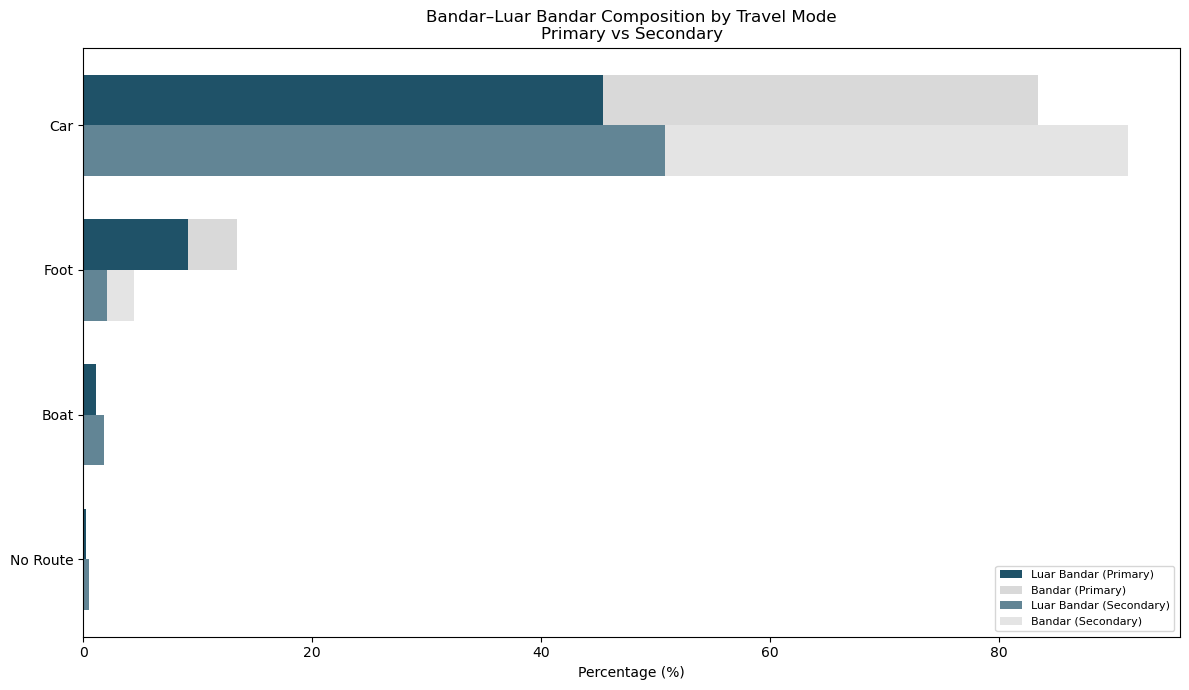

In [27]:
df = merged_pt_pct.copy()

primary_cols = {
    "Car": "car_primary",
    "Foot": "foot_primary",
    "Boat": "boat_primary",
    "No Route": "no_route_primary"
}

secondary_cols = {
    "Car": "car_secondary",
    "Foot": "foot_secondary",
    "Boat": "boat_secondary",
    "No Route": "no_route_secondary"
}

modes = list(primary_cols.keys())

# --------------------------------------------------------
# Build clean, mode-indexed dataframe
# --------------------------------------------------------
rows = []
for mode in modes:
    rows.append({
        "mode": mode,
        "primary_urban": df.loc["Bandar", primary_cols[mode]],
        "primary_rural": df.loc["Luar Bandar", primary_cols[mode]],
        "secondary_urban": df.loc["Bandar", secondary_cols[mode]],
        "secondary_rural": df.loc["Luar Bandar", secondary_cols[mode]],
    })

plot_df = pd.DataFrame(rows).set_index("mode")

# --------------------------------------------------------
# Side-by-side stacked bars ONLY
# --------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12, 7))

urban_colour = "#d9d9d9"
rural_colour = "#1F5268"

y = np.arange(len(plot_df))
bar_height = 0.35

# PRIMARY (upper bar)
ax1.barh(
    y - bar_height/2,
    plot_df["primary_rural"],
    height=bar_height,
    color=rural_colour,
    label="Luar Bandar (Primary)"
)
ax1.barh(
    y - bar_height/2,
    plot_df["primary_urban"],
    left=plot_df["primary_rural"],
    height=bar_height,
    color=urban_colour,
    label="Bandar (Primary)"
)

# SECONDARY (lower bar)
ax1.barh(
    y + bar_height/2,
    plot_df["secondary_rural"],
    height=bar_height,
    color=rural_colour,
    alpha=0.7,
    label="Luar Bandar (Secondary)"
)
ax1.barh(
    y + bar_height/2,
    plot_df["secondary_urban"],
    left=plot_df["secondary_rural"],
    height=bar_height,
    color=urban_colour,
    alpha=0.7,
    label="Bandar (Secondary)"
)

# Labels and layout
ax1.set_yticks(y)
ax1.set_yticklabels(plot_df.index)
ax1.set_title("Bandar–Luar Bandar Composition by Travel Mode\nPrimary vs Secondary")
ax1.set_xlabel("Percentage (%)")
ax1.invert_yaxis()
ax1.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()


Detailed plot on how travel modes changed

In [28]:
# Merge different travel modes between primary and secondary school

secondary_travel_mode = secondary_combined_routes_gdf[["pop_id","travel_mode"]].rename(columns={"travel_mode":"travel_mode_sec"})
primary_travel_mode = primary_combined_routes_gdf[["pop_id","travel_mode"]].rename(columns={"travel_mode":"travel_mode_pri"})

merged_travel_modes = primary_travel_mode.merge(
    secondary_travel_mode,
    on="pop_id",
    how="outer"
)

In [29]:
# Categorise columns

# Initialise column
merged_travel_modes["travel_mode_change"] = "other_change"

# Foot → Boat
merged_travel_modes.loc[
    (merged_travel_modes["travel_mode_pri"] == "foot") &
    (merged_travel_modes["travel_mode_sec"] == "boat"),
    "travel_mode_change"
] = "foot_to_boat"

# Foot → Car
merged_travel_modes.loc[
    (merged_travel_modes["travel_mode_pri"] == "foot") &
    (merged_travel_modes["travel_mode_sec"] == "car"),
    "travel_mode_change"
] = "foot_to_car"

# Foot → No Route
merged_travel_modes.loc[
    (merged_travel_modes["travel_mode_pri"] == "foot") &
    (merged_travel_modes["travel_mode_sec"] == "no_route"),
    "travel_mode_change"
] = "foot_to_no_route"

# Car → Boat
merged_travel_modes.loc[
    (merged_travel_modes["travel_mode_pri"] == "car") &
    (merged_travel_modes["travel_mode_sec"] == "boat"),
    "travel_mode_change"
] = "car_to_boat"

# Car → No Route
merged_travel_modes.loc[
    (merged_travel_modes["travel_mode_pri"] == "car") &
    (merged_travel_modes["travel_mode_sec"] == "no_route"),
    "travel_mode_change"
] = "car_to_no_route"

# No change
merged_travel_modes.loc[
    (merged_travel_modes["travel_mode_pri"]) ==
    (merged_travel_modes["travel_mode_sec"]),
    "travel_mode_change"
] = "no_change"


In [30]:
# Merge with a complete population dataset

# First merge population dataset
merged_pop_gdf = total_pop_gdf.merge(primary_pop_gdf[["pop_id","primary_school_students"]],on="pop_id",how="left").merge(secondary_pop_gdf[["pop_id","secondary_school_students"]],on="pop_id",how="left")
merged_pop_gdf = merged_pop_gdf[["pop_id","x","y","total_population","primary_school_students","secondary_school_students","bandar_luarbandar","geometry"]]
merged_pop_gdf = merged_pop_gdf.rename(columns={
    "x":"pop_x",
    "y":"pop_y"
})

# Next merge with travel modes and category
merged_pop_travel_mode = merged_pop_gdf.merge(
    merged_travel_modes,
    on="pop_id",
    how="outer"
)

In [31]:
# Simplify the primary and secondary school routes

# Filter the primary and secondary school routes
primary_combined_routes_gdf_filtered = primary_combined_routes_gdf[["pop_id","travel_mode","geometry"]]
secondary_combined_routes_gdf_filtered = secondary_combined_routes_gdf[["pop_id","travel_mode","geometry"]]

# Simplify geometry
tolerance = 0.00001  # ~1 metre, adjust if needed

primary_combined_routes_gdf_filtered["geometry"] = (
    primary_combined_routes_gdf_filtered["geometry"]
    .simplify(tolerance, preserve_topology=True)
)

secondary_combined_routes_gdf_filtered["geometry"] = (
    secondary_combined_routes_gdf_filtered["geometry"]
    .simplify(tolerance, preserve_topology=True)
)


In [32]:
# Create interactive map

# -----------------------------
# 0. Define output folders
# -----------------------------

base_output_folder = output_folder_maps   # your original output folder
assets_folder = os.path.join(base_output_folder, "assets")
os.makedirs(assets_folder, exist_ok=True)

# HTML output file
output_path = os.path.join(
    base_output_folder,
    "swk_travel_mode_change_interactive_map.html"
)

# -----------------------------
# 1. Create gdfs for layers
# -----------------------------

foot_boat = merged_pop_travel_mode[merged_pop_travel_mode["travel_mode_change"] == "foot_to_boat"]
foot_car = merged_pop_travel_mode[merged_pop_travel_mode["travel_mode_change"] == "foot_to_car"]
foot_no_route = merged_pop_travel_mode[merged_pop_travel_mode["travel_mode_change"] == "foot_to_no_route"]

car_boat = merged_pop_travel_mode[merged_pop_travel_mode["travel_mode_change"] == "car_to_boat"]
car_no_route = merged_pop_travel_mode[merged_pop_travel_mode["travel_mode_change"] == "car_to_no_route"]

no_change = merged_pop_travel_mode[merged_pop_travel_mode["travel_mode_change"] == "no_change"]

other_change = merged_pop_travel_mode[merged_pop_travel_mode["travel_mode_change"] == "other_change"]

# -----------------------------
# 2. Build colors for the combined routes
# -----------------------------

travel_mode_dict = {
    "car":  "#000000eb",   # black
    "foot": "#6200ffeb",   # purple
    "boat": "#00318DFF"    # blue
}

# Primary school
primary_combined_routes_gdf_filtered["colour"] = (
    primary_combined_routes_gdf_filtered["travel_mode"]
    .map(travel_mode_dict)
    .astype("object")   
)

# Secondary school
secondary_combined_routes_gdf_filtered["colour"] = (
    secondary_combined_routes_gdf_filtered["travel_mode"]
    .map(travel_mode_dict)
    .astype("object")   
)

# -----------------------------
# 3. Build the interactive map
# -----------------------------

x = (merged_pop_travel_mode["pop_x"].max() + merged_pop_travel_mode["pop_x"].min()) / 2
y = (merged_pop_travel_mode["pop_y"].max() + merged_pop_travel_mode["pop_y"].min()) / 2

m = leafmap.Map(height="600px", center=[x, y], use_message_queue=True, style="street")

# Basemap
m.add_basemap("Esri.WorldImagery", before_id=m.first_symbol_layer_id, visible=False)
m.add_tile_layer(
    url="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="Esri.WorldImagery (Basemap)",
    attribution="Esri World Imagery",
    visible=True
)

# -----------------------------
# 4. Create Population Data Layers
# -----------------------------
# foot to boat
m.add_gdf(
    gdf=foot_boat,
    name="Foot to Boat",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#00E5FF"},
    visible=True
)

# foot to car
m.add_gdf(
    gdf=foot_car,
    name="Foot to Car",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#4DD0E1"},
    visible=True
)

# foot to no route
m.add_gdf(
    gdf=foot_no_route,
    name="Foot to No Route",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#0097A7"},
    visible=True
)

m.add_gdf(
    gdf=car_boat,
    name="Car to Boat",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#FFB300"},
    visible=True
)

m.add_gdf(
    gdf=car_no_route,
    name="Car to No Route",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#FB8C00"},
    visible=True
)

m.add_gdf(
    gdf=no_change,
    name="No Change",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#000000"},
    visible=True
)

m.add_gdf(
    gdf=other_change,
    name="Other Change",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": "#FFFFFF"},
    visible=True
)

# -----------------------------
# 5. Routes
# -----------------------------

# Plot the secondary routes
m.add_gdf(
    gdf=secondary_combined_routes_gdf_filtered,
    name="Secondary School Routes",
    layer_type="line",
    paint={"line-color": ["get","colour"]},
    visible=True
)

# Plot the primary routes
m.add_gdf(
    gdf=primary_combined_routes_gdf_filtered,
    name="Primary School Routes",
    layer_type="line",
    paint={"line-color": ["get","colour"]}
)

# -----------------------------
# 6. Adminstrative Boundaries
# -----------------------------

# Adminstrative boundaries
m.add_gdf(
    gdf=swk_districts_gdf,
    name="District Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=True
)

m.add_gdf(
    gdf=swk_parlimen_gdf,
    name="Parlimen Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)

m.add_gdf(
    gdf=swk_dun_gdf,
    name="DUN Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)


# -----------------------------
# 7. Add school layers
# -----------------------------

# -- Primary Schools ---
image_pri = "Interactive Maps/assets/icons/college_blue.png"

primary_geojson = json.loads(primary_school_gdf.to_json())
source_pri = {"type": "geojson", "data": primary_geojson}

layer_pri = {
    "id": "Primary Schools",
    "type": "symbol",
    "source": "point_pri",
    "layout": {
        "icon-image": "pri_school",
        "icon-size": 0.08}
}

m.add_image("pri_school", image_pri)
m.add_source("point_pri", source_pri)
m.add_layer(layer_pri)
m.add_popup("Primary Schools")

# -- Secondary Schools ---
image_sec = "Interactive Maps/assets/icons/college_orange.png"

secondary_geojson = json.loads(secondary_school_gdf.to_json())
source_sec = {"type": "geojson", "data": secondary_geojson}

layer_sec = {
    "id": "Secondary Schools",
    "type": "symbol",
    "source": "point_sec",
    "layout": {
        "icon-image": "sec_school",
        "icon-size": 0.08}
}

m.add_image("sec_school", image_sec)
m.add_source("point_sec", source_sec)
m.add_layer(layer_sec)
m.add_popup("Secondary Schools")

# -----------------------------
# 8. Add legend
# -----------------------------

# Legend for travel time
legend_dict = {
    "Foot to Boat":      "#00E5FF",   # bright cyan
    "Foot to Car":       "#4DD0E1",   # light teal
    "Foot to No Route":  "#0097A7",   # deep turquoise

    "Car to Boat":       "#FFB300",   # bright amber
    "Car to No Route":   "#FB8C00",   # burnt orange

    "No Change":         "#000000",   # black
    "Other Change":      "#FFFFFF"    # white
}


m.add_legend(
    title = "Change in Travel Mode",
    legend_dict = legend_dict,
    position = "bottom-right"
)

# Legend for travel mode
travel_mode_dict = {
    "car":  "#000000eb",   # black
    "foot": "#6200ffeb",   # purple
    "boat": "#00318DFF"    # blue
}

m.add_legend(
    title = "Travel Mode",
    legend_dict = travel_mode_dict,
    position = "bottom-right"
)

# -----------------------------
# 9. Add map title / sources
# -----------------------------

m.add_text(
    "Change in Travel Mode between Secondary and Primary School",
    position="top-left",
    font_size=12
)

# -----------------------------
# 10. Layer control
# -----------------------------

m.add_layer_control(
    layer_ids=[
        "Foot to Boat",
        "Foot to Car",
        "Foot to No Route",
        "Car to Boat",
        "Car to No Route",
        "No Change",
        "Other Change",
        "Primary Schools",
        "Secondary Schools",
        "Primary School Routes",
        "Secondary School Routes",
        "District Boundaries",
        "Parlimen Boundaries",
        "DUN Boundaries",
        "Esri.WorldImagery (Basemap)"
    ],
    position="top-left"
)

# -----------------------------
# 12. Export HTML
# -----------------------------

m.to_html(
    output=output_path,
    title="Change in Travel Mode between Secondary and Primary School",
    overwrite=True
)

m

Html(children=[<leafmap.maplibregl.Map object at 0x000001E6BC2E0520>, Card(children=[Btn(children=[Icon(childr…